In [1]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
ENV_NAME = "☁️ Google Colab" if IN_COLAB else "💻 Ambiente Local (WSL/Jupyter)"

print(f"Detectado: {ENV_NAME}")
print(f"Versão do Python: {sys.version.split()[0]}")

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/"
    SAVE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/3_golden_data/"
else:
    BASE_PATH = "../2_silver_data/"
    SAVE_PATH = "../3_golden_data/"

Detectado: ☁️ Google Colab
Versão do Python: 3.12.13
Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.dataset as ds
from scipy import stats

In [22]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.api import VAR, VARMAX
from statsmodels.tsa.seasonal import seasonal_decompose

### Importação de dados

In [3]:
s_diario_volume_abertura = pd.read_csv(filepath_or_buffer=f"{BASE_PATH}s_diario_volume_abertura.csv", sep=";", encoding='ISO-8859-1', parse_dates=['data'])
s_diario_volume_abertura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   data                      1095 non-null   datetime64[ns]
 1   inc_abertos               1095 non-null   int64         
 2   inc_abertos_p1            1095 non-null   int64         
 3   inc_abertos_p2            1095 non-null   int64         
 4   inc_abertos_p3            1095 non-null   int64         
 5   inc_abertos_p4            1095 non-null   int64         
 6   inc_abertos_p5            1095 non-null   int64         
 7   inc_abertos_ac_mes        1095 non-null   int64         
 8   inc_abertos_ac_ano        1095 non-null   int64         
 9   inc_abertos_ac_30d        1095 non-null   int64         
 10  inc_abertos_ac_7d         1095 non-null   int64         
 11  inc_abertos_madrugada     1095 non-null   int64         
 12  inc_abertos_manha   

In [4]:
s_diario_temporal = pd.read_csv(filepath_or_buffer=f"{BASE_PATH}s_diario_temporal.csv", sep=";", encoding='ISO-8859-1', parse_dates=['data'])
s_diario_temporal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          1095 non-null   datetime64[ns]
 1   feriado       1095 non-null   int64         
 2   nome_feriado  44 non-null     object        
 3   dia_semana    1095 non-null   int64         
 4   dia_util      1095 non-null   int64         
 5   mes           1095 non-null   int64         
 6   trimestre     1095 non-null   int64         
 7   dia_mes       1095 non-null   int64         
 8   num_dia_util  1095 non-null   int64         
 9   ano_mes       1095 non-null   object        
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 85.7+ KB


In [5]:
s_diario_monitoramento = pd.read_csv(filepath_or_buffer=f"{BASE_PATH}s_diario_monitoramento.csv", sep=";", encoding='ISO-8859-1', parse_dates=['data'])
s_diario_monitoramento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data               1095 non-null   datetime64[ns]
 1   inc                1095 non-null   int64         
 2   inc_mon            1095 non-null   int64         
 3   taxa_mon_diario    1095 non-null   float64       
 4   inc_ac_mes         1095 non-null   int64         
 5   inc_ac_mon_mes     1095 non-null   int64         
 6   taxa_mon_ac_mes    1095 non-null   float64       
 7   inc_ac_geral       1095 non-null   int64         
 8   inc_ac_mon_geral   1095 non-null   int64         
 9   taxa_mon_ac_geral  1095 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(6)
memory usage: 85.7 KB


In [6]:
s_diario_itens_config = pd.read_csv(filepath_or_buffer=f"{BASE_PATH}s_diario_itens_config.csv", sep=";", encoding='ISO-8859-1', parse_dates=['data'])
s_diario_itens_config.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 1095 non-null   datetime64[ns]
 1   ics_outliers_ativos  1095 non-null   int64         
 2   ics_inativos         1095 non-null   int64         
 3   ics_total            1095 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 34.3 KB


In [7]:
s_diario_volume_fechamento = pd.read_csv(filepath_or_buffer=f"{BASE_PATH}s_diario_volume_fechamento.csv", sep=";", encoding='ISO-8859-1', parse_dates=['data'])
s_diario_volume_fechamento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   data                       1095 non-null   datetime64[ns]
 1   inc                        1095 non-null   float64       
 2   inc_fechados_p1            1095 non-null   float64       
 3   inc_fechados_p2            1095 non-null   float64       
 4   inc_fechados_p3            1095 non-null   float64       
 5   inc_fechados_p4            1095 non-null   float64       
 6   inc_fechados_p5            1095 non-null   float64       
 7   inc_fechados_ac_mes        1095 non-null   float64       
 8   inc_fechados_ac_ano        1095 non-null   float64       
 9   inc_fechados_ac_30d        1095 non-null   float64       
 10  inc_fechados_ac_7d         1095 non-null   float64       
 11  inc_p2_fechados_ac_mes     1095 non-null   float64       
 12  inc_p3

In [8]:
s_diario_status_fechamento = pd.read_csv(filepath_or_buffer=f"{BASE_PATH}s_diario_status_fechamento.csv", sep=";", encoding='ISO-8859-1', parse_dates=['data'])
s_diario_status_fechamento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   data                       1095 non-null   datetime64[ns]
 1   total_incidentes_fechados  1095 non-null   int64         
 2   inc_stat_ea                1095 non-null   int64         
 3   inc_stat_e                 1095 non-null   int64         
 4   inc_stat_si                1095 non-null   int64         
 5   taxa_stat_ea_diario        1095 non-null   float64       
 6   taxa_stat_e_diario         1095 non-null   float64       
 7   taxa_stat_si_diario        1095 non-null   float64       
 8   inc_fechados_ac_mes        1095 non-null   float64       
 9   inc_ac_stat_ea_mes         1095 non-null   int64         
 10  inc_ac_stat_e_mes          1095 non-null   int64         
 11  inc_ac_stat_si_mes         1095 non-null   int64         
 12  taxa_s

### Data Processing

In [11]:
serie_temporal = pd.melt(
    s_diario_volume_abertura,
    id_vars=['data'], # A coluna que deve continuar intacta/fixa
    value_vars=['inc_abertos_p1', 'inc_abertos_p2', 'inc_abertos_p3', 'inc_abertos_p4', 'inc_abertos_p5'], # As colunas que vão virar variáveis
    var_name='prioridade', # O nome da nova coluna que vai receber os nomes (inc_p1, etc.)
    value_name='qtd_inc' # O nome da nova coluna que vai receber os valores numéricos
)
serie_temporal['prioridade'] = serie_temporal['prioridade'].str.replace('inc_abertos_p', '').astype(int)
serie_temporal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        5475 non-null   datetime64[ns]
 1   prioridade  5475 non-null   int64         
 2   qtd_inc     5475 non-null   int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 128.4 KB


In [12]:
serie_temporal.sort_values(by=['data', 'prioridade'], inplace=True)
serie_temporal.tail(20)

,data,prioridade,qtd_inc
1091,2025-12-28,1,0
2186,2025-12-28,2,46
3281,2025-12-28,3,391
4376,2025-12-28,4,392
5471,2025-12-28,5,0
1092,2025-12-29,1,0
2187,2025-12-29,2,57
3282,2025-12-29,3,515
4377,2025-12-29,4,349
5472,2025-12-29,5,0


In [13]:
serie_temporal.head(20)

,data,prioridade,qtd_inc
0,2023-01-02,1,0
1095,2023-01-02,2,0
2190,2023-01-02,3,1
3285,2023-01-02,4,0
4380,2023-01-02,5,0
1,2023-01-03,1,0
1096,2023-01-03,2,0
2191,2023-01-03,3,0
3286,2023-01-03,4,0
4381,2023-01-03,5,0


In [28]:
df_p2 = serie_temporal[serie_temporal['prioridade'] == 2].copy()
df_p3 = serie_temporal[serie_temporal['prioridade'] == 3].copy()
df_p4 = serie_temporal[serie_temporal['prioridade'] == 4].copy()

In [29]:
dfs = {
    "p2": df_p2,
    "p3": df_p3,
    "p4": df_p4
}
priorities = ["p2", "p3", "p4"]

for p in priorities:
  dfs[p].set_index('data', inplace=True)
  dfs[p].drop(columns='prioridade', inplace=True)
  dfs[p].sort_index(inplace=True)
  dfs[p] = dfs[p][dfs[p].index.year >= 2025]

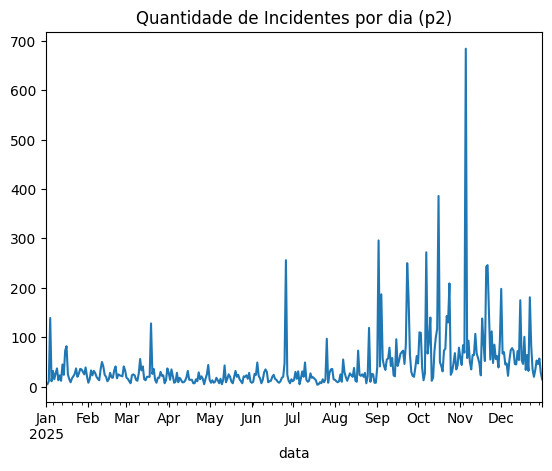

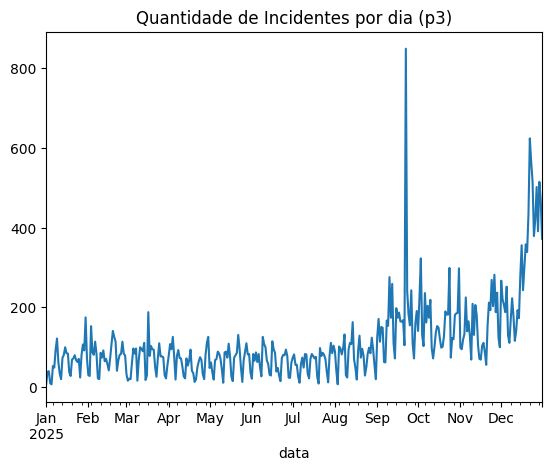

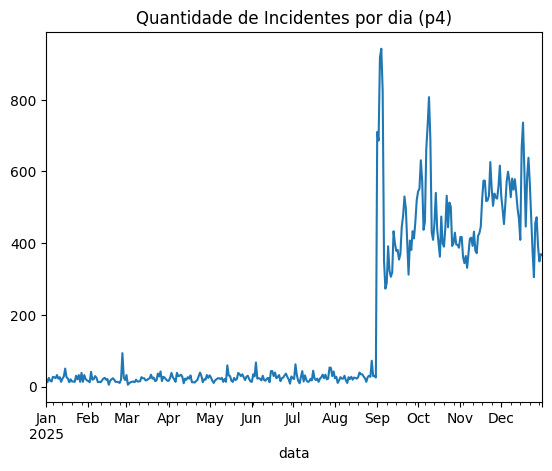

In [30]:
# Plotagem da série
for p in priorities:
  series = dfs[p]['qtd_inc']
  series.plot(title=f"Quantidade de Incidentes por dia ({p})")
  plt.show()


Decomposição da série temporal (p2):


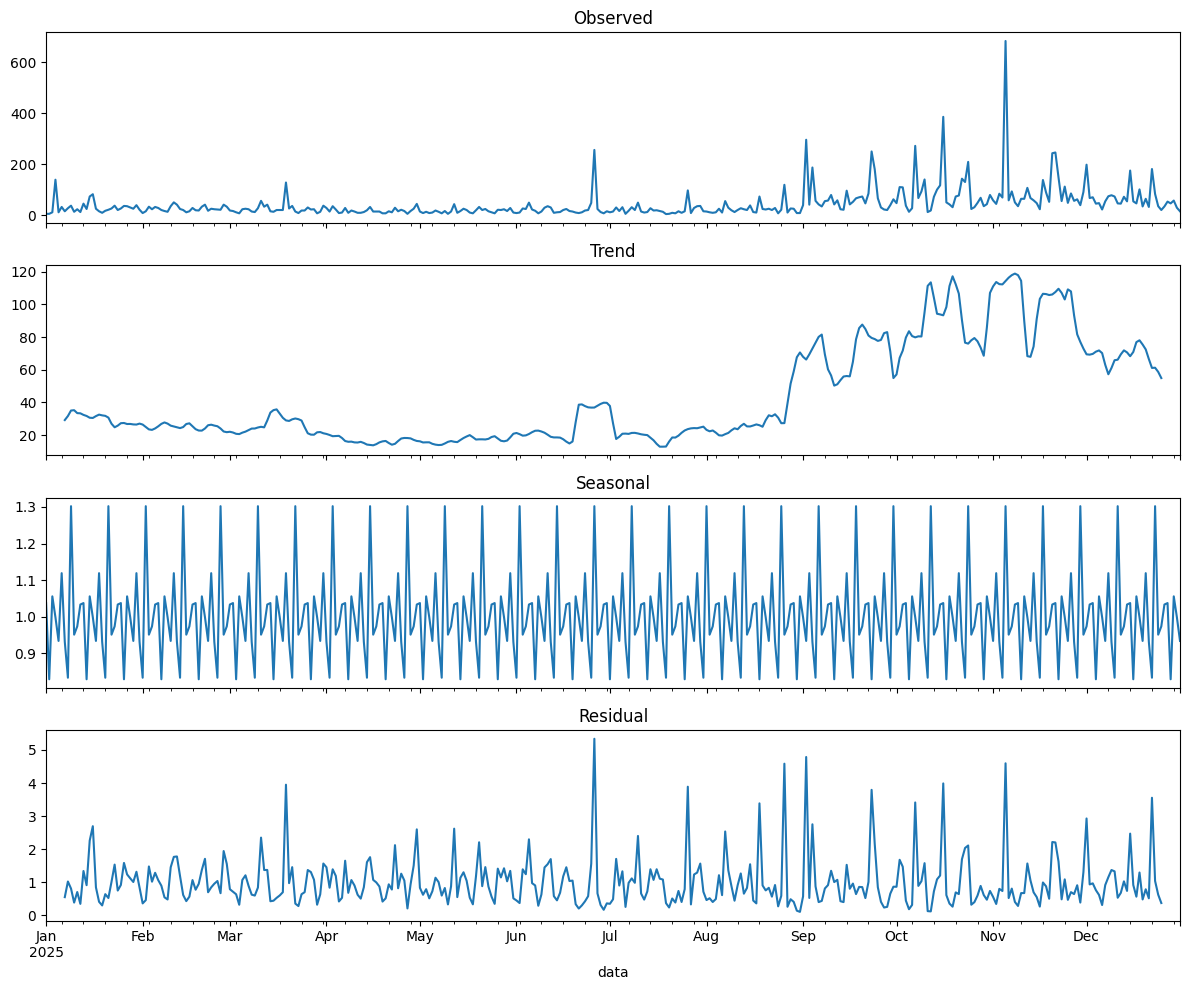


Decomposição da série temporal (p3):


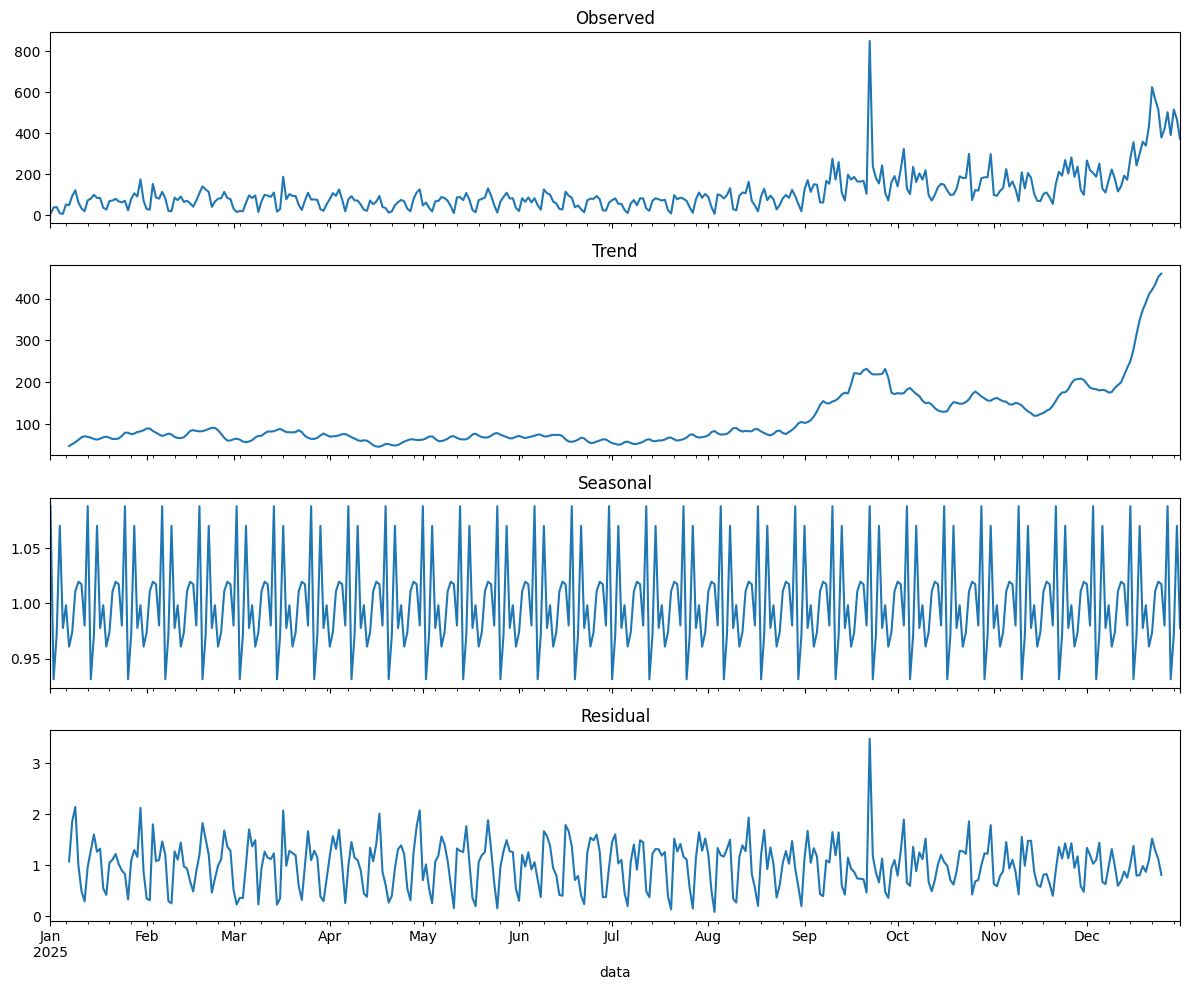


Decomposição da série temporal (p4):


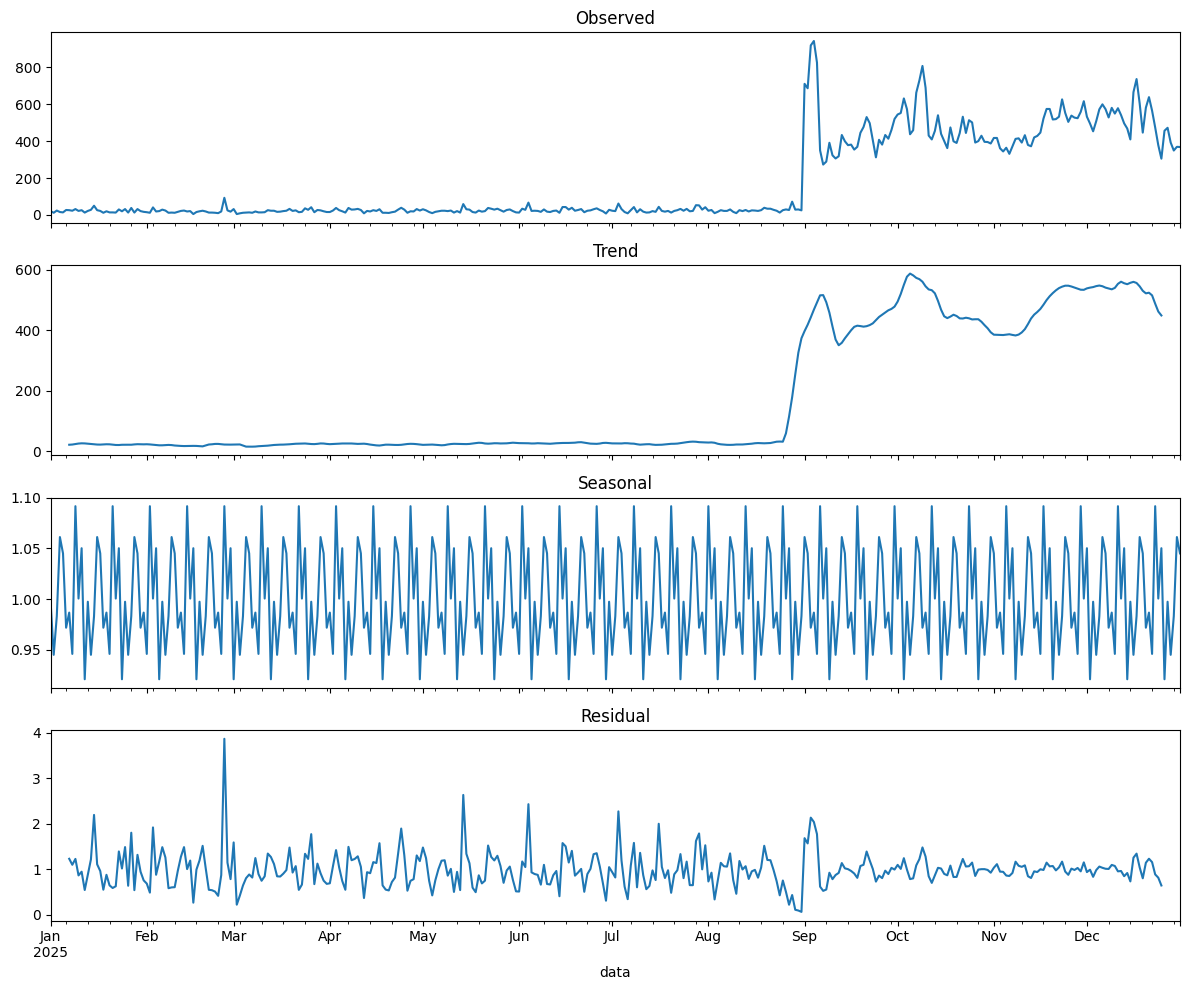

In [32]:
for p in priorities:
  print(f"\nDecomposição da série temporal ({p}):")
  decomposition = seasonal_decompose(dfs[p], model='multiplicative', period=12)
  fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
  # Serie original, é a serie que estamos analisando, combinando todos os componentes
  decomposition.observed.plot(ax=ax1)
  ax1.set_title('Observed')
  # Tendência, representa a direção de longo prazo da serie
  decomposition.trend.plot(ax=ax2)
  ax2.set_title('Trend')
  # Sazonalidade, reflete padrões que se repetem em intervalos fixos e conhecidos
  decomposition.seasonal.plot(ax=ax3)
  ax3.set_title('Seasonal')
  # Residuo, conhecido como componente irregular ou ruido, é o que resta da serie tirando a tendencia e sazonalidade
  decomposition.resid.plot(ax=ax4)
  ax4.set_title('Residual')
  plt.tight_layout()
  plt.show()

### Training AR

In [35]:
# AR (AutoRegressive) Model
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.ar_model import ar_select_order
import numpy as np
import pandas as pd # Importar pandas para pd.offsets
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import ar_select_order

#### P2

In [36]:
# Dividir a série em conjunto de treino e teste
# Usaremos 80% dos dados para treino e 20% para teste
train_size = int(len(dfs["p2"]) * 0.8)
train, test = dfs["p2"][0:train_size], dfs["p2"][train_size:]

In [39]:
# Escolhendo o melhor lag automaticamente
# maxlag é o limite máximo que ele vai testar (ex: 24 meses).
# ic='aic' é o critério de Akaike (quanto menor o AIC, melhor o modelo).
selecao_lags = ar_select_order(train, maxlag=60, ic='aic')
lags_ideais = selecao_lags.ar_lags
print(f"\nOs melhores lags escolhidos automaticamente foram: {lags_ideais}")


Os melhores lags escolhidos automaticamente foram: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [41]:
# 1. Aplicando a primeira diferença para remover a tendência
# O dropna() é necessário porque o primeiro dia não tem um dia anterior para subtrair
train_diff = train.diff().dropna()

# 2. Agora sim, buscamos os melhores lags na série SEM tendência
selecao_lags = ar_select_order(train_diff, maxlag=60, ic='aic')
lags_ideais = selecao_lags.ar_lags
print(f"\nOs melhores lags para a série diferenciada são: {lags_ideais}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



Os melhores lags para a série diferenciada são: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


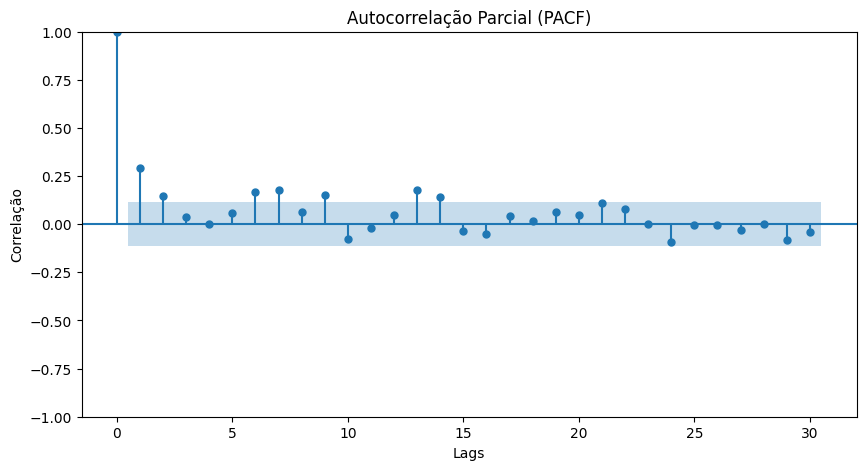

In [42]:
# Plota o PACF para os dados de treino testando até 30 lags
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(train, lags=30, ax=ax)
plt.title("Autocorrelação Parcial (PACF)")
plt.xlabel("Lags")
plt.ylabel("Correlação")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)



### Sumário do Modelo AutoReg ###
                            AutoReg Model Results                             
Dep. Variable:                qtd_inc   No. Observations:                  292
Model:                     AutoReg(7)   Log Likelihood               -1451.078
Method:               Conditional MLE   S.D. of innovations             39.353
Date:                Thu, 20 Aug 2026   AIC                           2920.157
Time:                        00:23:55   BIC                           2953.029
Sample:                    01-08-2025   HQIC                          2933.334
                         - 10-19-2025                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4477      4.025      2.596      0.009       2.559      18.337
qtd_inc.L1     0.1995      0.058      3.445      0.001       0.086       0.313
qtd_inc.L2     0.

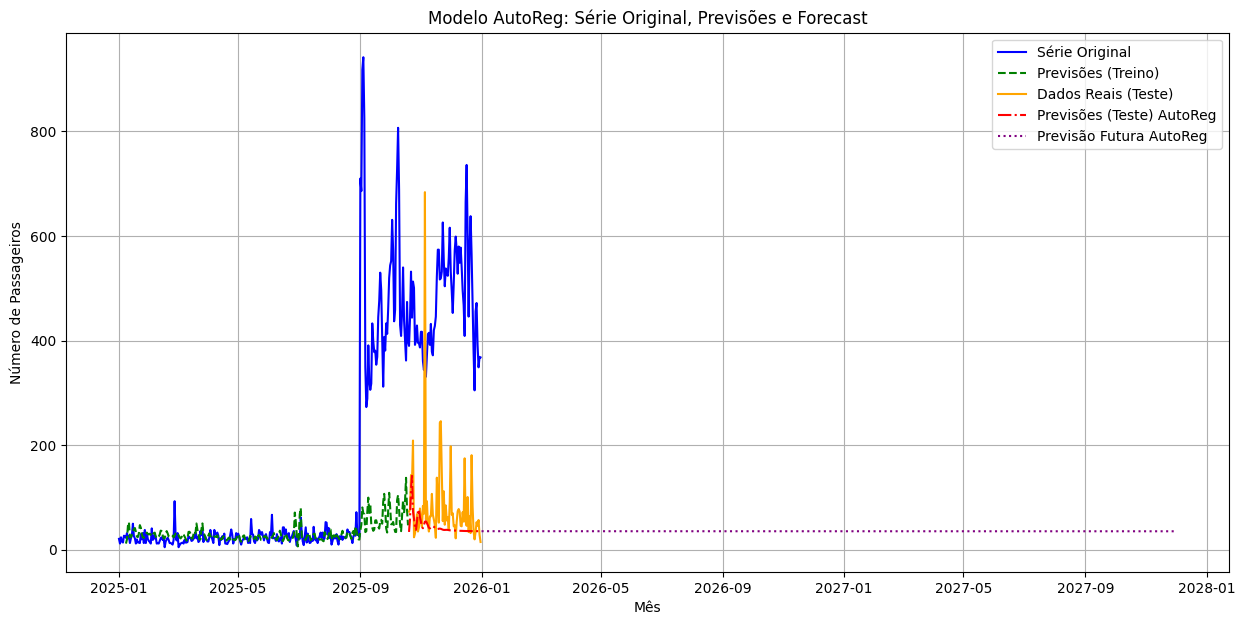

In [43]:
# Ajustar o modelo AutoReg no conjunto de treino
lags = 7

model_ar = AutoReg(train, lags=lags).fit()

# Imprimir o sumário do modelo
print("\n### Sumário do Modelo AutoReg ###")
print(model_ar.summary())

# Fazer previsões no conjunto de teste (out-of-sample prediction)
# O start e o end devem corresponder aos índices do conjunto de teste
start_test_index = len(train)
end_test_index = len(series) - 1
predictions_test = model_ar.predict(start=start_test_index, end=end_test_index)

# Calcular métricas de erro para as previsões do conjunto de teste
mse = mean_squared_error(test, predictions_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, predictions_test)

print(f"\n### Métricas de Erro (Out-of-Sample) ###")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Fazer previsões futuras (forecast)
# Vamos prever 24 meses além do final da série original
forecast_steps = 24
forecast = model_ar.predict(start=len(series), end=len(series) + forecast_steps - 1)

# Criar um índice para as previsões futuras
forecast_index = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(), periods=forecast_steps, freq='MS')
forecast.index = forecast_index

# Visualização das projeções
plt.figure(figsize=(15, 7))
plt.plot(series, label="Série Original", color='blue')
# Correção: O predict para o treino começa após o número de lags
plt.plot(train.index[lags:], model_ar.predict(start=lags, end=len(train)-1), label="Previsões (Treino)", color='green', linestyle='--')
plt.plot(test.index, test, label="Dados Reais (Teste)", color='orange')
plt.plot(predictions_test.index, predictions_test, label="Previsões (Teste) AutoReg", color='red', linestyle='-.')
plt.plot(forecast.index, forecast, label="Previsão Futura AutoReg", color='purple', linestyle=':')
plt.title("Modelo AutoReg: Série Original, Previsões e Forecast")
plt.xlabel("Mês")
plt.ylabel("Número de Passageiros")
plt.legend()
plt.grid(True)
plt.show()

### Training LSTM

In [ ]:
training_table = serie_temporal.copy()
training_table.head()

In [ ]:
training_table['dia_anterior'] = training_table['data'] - pd.Timedelta(days=1)
training_table.head()

In [ ]:
# unindo as features temporais - devem usar o dia real
training_table = training_table.merge(
    s_diario_temporal[['data', 'feriado', 'dia_semana', 'dia_util']],
    on='data',
    how='left'
)

# unindo as features de fechamento de incidentes - devem usar o dia anterior
# Correção: removida a duplicata de 'taxa_stat_e_diario' e aplicada a renomeação da chave
training_table = training_table.merge(
    s_diario_volume_fechamento[['data', 'inc_fechados_ac_7d']].rename(columns={'data': 'dia_anterior'}),
    on='dia_anterior',
    how='left'
)

# unindo as features de monitoramento - devem usar o dia anterior
training_table = training_table.merge(
    s_diario_monitoramento[['data', 'taxa_mon_diario']].rename(columns={'data': 'dia_anterior'}),
    on='dia_anterior',
    how='left'
)

# unindo as features relacionadas aos ics - devem usar o dia anterior
training_table = training_table.merge(
    s_diario_itens_config[['data', 'ics_outliers_ativos', 'ics_inativos']].rename(columns={'data': 'dia_anterior'}),
    on='dia_anterior',
    how='left'
)

In [ ]:
# Tabela final de treinamento
training_table_final = training_table.drop(columns=['dia_anterior'])
training_table_final.info()

In [ ]:
# Transformando a coluna data em index
training_table_final['data_prioridade'] = training_table_final['data'].astype(str) + '_p' + training_table_final['prioridade'].astype(str)
training_table_final.reset_index(drop=True, inplace=True)
training_table_final.set_index('data_prioridade', inplace=True)
training_table_final.head()